In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
### loading packages
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = np.loadtxt('./drive/MyDrive/sindata_1000.csv', delimiter=',')
data.shape

(1000,)

In [4]:
split = int(0.8 * len(data))
print(f'数据大小为 {len(data)}')

数据大小为 1000


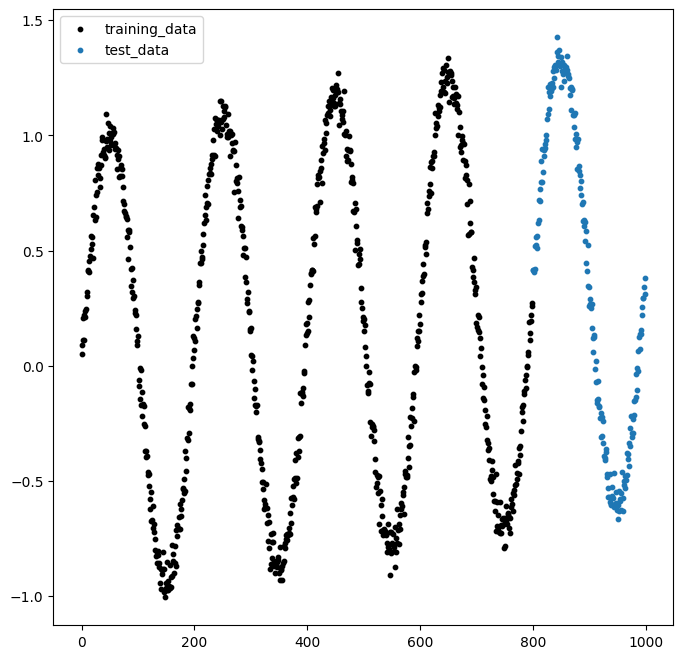

In [5]:
plt.figure(figsize=(8,8))
plt.scatter(np.arange(split), data[:split], c = 'black', s = 10, label = 'training_data')
plt.scatter(np.arange(split, len(data)), data[split:], c = None, s = 10, label = 'test_data')
plt.legend()
plt.show()

In [6]:
train_data = data[:split]
test_data = data[split:]

In [7]:
seq_len = 20
train_num = len(train_data) // (seq_len + 1) * (seq_len + 1)
train_data = train_data[:train_num].reshape(-1, seq_len + 1, 1)
np.random.seed(0)
torch.manual_seed(0)

x_train = torch.from_numpy(train_data[:,:seq_len,:]).float()
y_train = torch.from_numpy(train_data[:,1:seq_len+1,:]).float()

x_test = torch.from_numpy(test_data[:-1]).float()
y_test = torch.from_numpy(test_data[1:]).float()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

torch.Size([38, 20, 1])
torch.Size([38, 20, 1])
torch.Size([199])
torch.Size([199])


In [8]:
class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super().__init__()
    self.gru = nn.GRU(input_size = input_size, hidden_size = hidden_size, batch_first=True, num_layers= 1)
    ### 输入格式是(batch_size, seq_len, input_size)
    self.linear = nn.Linear(hidden_size, output_size)
    self.hidden_size = hidden_size

  def forward(self, x, hidden): ### x 的维度是(batch_size, seq_len, input_size)
    out, hidden = self.gru(x, hidden) ## hidden 的维度是(1, batch_size, hidden_size) out的维度是(batch_size, seq_len, hidden_size)
    out = self.linear(out.reshape(-1, self.hidden_size))
    return out, hidden

  def init_hidden(self, batch_size):
    return torch.zeros(1, batch_size, self.hidden_size).float().to('cuda')
if __name__ == '__main__':
  input_var = torch.randn(size = [10, 20, 1]).to('cuda')
  model = GRU(1, 10, 10).to('cuda')
  hidden = model.init_hidden(10)
  out, hidden  = model(input_var,hidden)
print(out.shape)

torch.Size([200, 10])


In [9]:
input_size = 1
output_size = 1
hidden_size = 16

gru = GRU(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
gru_optimizer = torch.optim.Adam(gru.parameters(), lr = 0.001)

def test_gru(gru, x, hidden, pred_steps):
  pred = []
  inp = x.view(-1, input_size)
  for i in range(pred_steps):
    out, hidden = gru(inp.unsqueeze(0), hidden)
    pred.append(out.detach())
    inp = out
    # print(pred)
  return torch.cat(pred, dim=0).view(-1)

# test_gru(gru, x_test[0].to('cuda'), gru.init_hidden(1).to('cuda'), 5)

In [14]:
hidden_1 = 32
hidden_2 = 16
mlp = nn.Sequential(
    nn.Linear(input_size, hidden_1),
    nn.ReLU(),
    nn.Linear(hidden_1, hidden_2),
    nn.ReLU(),
    nn.Linear(hidden_2, output_size)
)
mlp_optimizer = torch.optim.Adam(mlp.parameters(), lr = 0.001)
# sum([p.numel() for p in mlp.parameters()])

In [10]:
def test_mlp(mlp, x, pred_steps):
  pred = []
  # print(x)
  inp = x.view(-1, input_size)
  # print(inp.shape)
  for i in range(pred_steps):
    out = mlp(inp)
    pred.append(out.detach())
    inp = out
  return torch.cat(pred, dim=0).view(-1)
# test_mlp(mlp.to('cuda'), x_test[:5].to('cuda'), 10)

In [11]:
x_test[0].to('cuda')

tensor(0.4160, device='cuda:0')

In [15]:
from tqdm import tqdm
max_epoch = 150
criterion = nn.MSELoss()
hidden = None
gru_losses = []
mlp_losses = []
gru_test_losses = []
mlp_test_losses = []
with tqdm(range(max_epoch)) as pbar:
  for epoch in pbar:
    st = 0
    gru_loss = 0.0
    mlp_loss = 0.0
    for X, y in zip(x_train, y_train):
      if hidden is not None:
        hidden.detach_()
      gru_pred, hidden = gru(X.unsqueeze(0), hidden)
      gru_loss = criterion(gru_pred.view(y.shape),y)
      gru_optimizer.zero_grad()
      gru_loss.backward()
      gru_optimizer.step()
      gru_loss += gru_loss.item()

      mlp_pred = mlp(X)
      mlp_loss = criterion(mlp_pred, y)
      mlp_optimizer.zero_grad()
      mlp_loss.backward()
      mlp_optimizer.step()
      mlp_loss += mlp_loss.item()

    gru_loss /= len(x_train)
    mlp_loss /= len(x_train)
    gru_losses.append(gru_loss.item())
    mlp_losses.append(mlp_loss.item())

    gru_pred = test_gru(gru, x_test[0], hidden, len(y_test))
    mlp_pred = test_mlp(mlp, x_test[0], len(y_test))
    gru_test_loss = criterion(gru_pred, y_test)
    mlp_test_loss = criterion(mlp_pred, y_test)
    gru_test_losses.append(gru_test_loss.item())
    mlp_test_losses.append(mlp_test_loss.item())

    pbar.set_postfix({'Epoch': epoch,
                    'GRU loss': gru_loss,
                      'MLP loss': mlp_loss,
                      'GRU test loss': gru_test_loss,
                      'MLP test loss': mlp_test_loss})


100%|██████████| 150/150 [00:49<00:00,  3.04it/s, Epoch=149, GRU loss=tensor(0.0001, grad_fn=<DivBackward0>), MLP loss=tensor(0.0003, grad_fn=<DivBackward0>), GRU test loss=tensor(0.0073), MLP test loss=tensor(0.6114)]


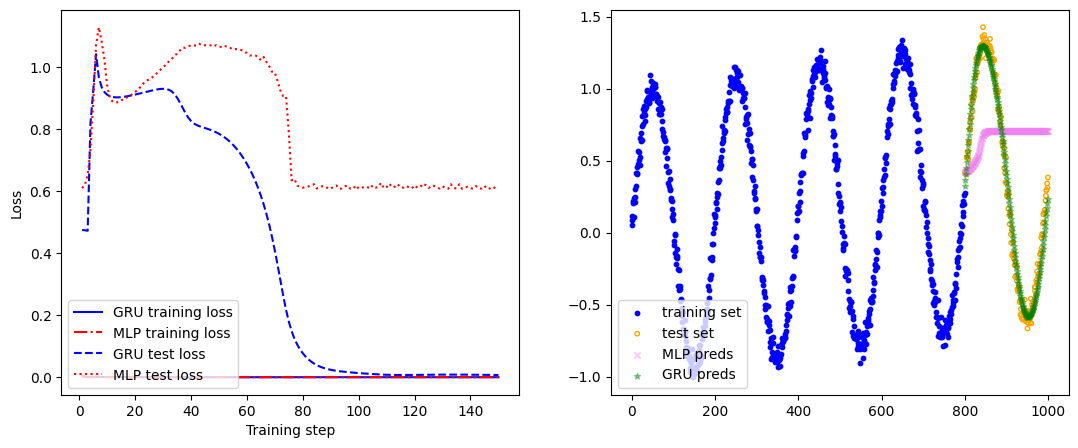

In [18]:
gru_preds = test_gru(gru, x_test[0], hidden, len(y_test)).numpy()
mlp_preds = test_mlp(mlp, x_test[0], len(y_test)).numpy()
num_data = len(data)
plt.figure(figsize=(13, 5))

# 绘制训练曲线
plt.subplot(121)
x_plot = np.arange(len(gru_losses)) + 1
plt.plot(x_plot, gru_losses, color='blue',
    label='GRU training loss')
plt.plot(x_plot, mlp_losses, color='red',
    ls='-.', label='MLP training loss')
plt.plot(x_plot, gru_test_losses, color='blue',
    ls='--', label='GRU test loss')
plt.plot(x_plot, mlp_test_losses, color='red',
    ls=':', label='MLP test loss')
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.legend(loc='lower left')

# 绘制真实数据与模型预测值的图像
plt.subplot(122)
plt.scatter(np.arange(split), data[:split], color='blue',
    s=10, label='training set')
plt.scatter(np.arange(split, num_data), data[split:], color='none',
    edgecolor='orange', s=10, label='test set')
plt.scatter(np.arange(split, num_data - 1), mlp_preds, color='violet',
    marker='x', alpha=0.4, s=20, label='MLP preds')
plt.scatter(np.arange(split, num_data - 1), gru_preds, color='green',
    marker='*', alpha=0.4, s=20, label='GRU preds')
plt.legend(loc='lower left')
plt.savefig('output_20_0.png')
plt.savefig('output_20_0.pdf')
plt.show()